# Round 4 — VE × VEV joint research

Companion to [`round4_options_research.md`](round4_options_research.md) and [`round4_ve_vev_research.md`](round4_ve_vev_research.md). The options notebook treats VEV in isolation; this one looks at the **underlying VE** and the **interaction** between VE flow and VEV flow.

## Questions to answer

1. **VE microstructure & counterparties.** Who trades VE? Same set as VEV or disjoint? Who is informed/passive on VE? (the options notebook only did this for VEV.)
2. **Lead-lag VE ↔ VEV.** When VEV mid moves, does VE move first/after? Cross-correlation at lags. Is the implied move (Δ × ΔS) consistent with realised VEV move?
3. **Joint CP behaviour.** Mark 01 buys VEV directionally; what does Mark 01 do on VE? Are CPs hedging across products, or trading them independently?
4. **Strategy primitives** that use both products jointly: synthetic long-vol baskets, one-shot delta-hedged hold-to-expiry, sizing gates.

Discipline carried in (L1–L7, [`round4_research.md`](round4_research.md) §0). Backtest is *gating filter*. No parameter sweeps. Sizing first; signal second.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = '../dataset/ROUND_4'
DAYS = [1, 2, 3]
TTE_BY_DAY = {1: 7/365, 2: 6/365, 3: 5/365}
STRIKES_TRADEABLE = [5200, 5300, 5400, 5500]
STRIKES_ALL = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]

## 1. Load data

In [2]:
prices, trades = [], []
for d in DAYS:
    p = pd.read_csv(f'{DATA_DIR}/prices_round_4_day_{d}.csv', sep=';'); p['day'] = d
    t = pd.read_csv(f'{DATA_DIR}/trades_round_4_day_{d}.csv', sep=';'); t['day'] = d
    prices.append(p); trades.append(t)
P = pd.concat(prices, ignore_index=True)
T = pd.concat(trades, ignore_index=True)

VE = P[P['product'] == 'VELVETFRUIT_EXTRACT'].sort_values(['day','timestamp']).reset_index(drop=True)
VE['spread'] = VE['ask_price_1'] - VE['bid_price_1']
S_df = VE[['day','timestamp','mid_price']].rename(columns={'mid_price':'S'})
VE_by_day = {d: VE[VE['day']==d].sort_values('timestamp').reset_index(drop=True) for d in DAYS}

T_VE  = T[T['symbol'] == 'VELVETFRUIT_EXTRACT'].copy()
T_VEV = T[T['symbol'].str.startswith('VEV_')].copy()

print(f'P rows: {len(P):,} | T rows: {len(T):,}')
print(f'VE prints (3d): {len(T_VE):,}')
print(f'VEV prints (3d): {len(T_VEV):,}')

P rows: 360,000 | T rows: 4,281
VE prints (3d): 1,381
VEV prints (3d): 1,878


## 2. VE counterparties — who's on the underlying tape

The options notebook only looked at VEV CPs (Mark 01 / 14 / 22 / 38). VE has a different set: **6 CPs** active vs VEV's **4**. Three of them — **Mark 49, 55, 67** — are VE-only and never appear in VEV prints.

In [3]:
cp_long_ve = pd.concat([
    T_VE[['buyer','quantity']].rename(columns={'buyer':'cp'}).assign(side='BUY'),
    T_VE[['seller','quantity']].rename(columns={'seller':'cp'}).assign(side='SELL'),
], ignore_index=True).dropna(subset=['cp'])

cp_long_vev = pd.concat([
    T_VEV[['buyer','quantity']].rename(columns={'buyer':'cp'}).assign(side='BUY'),
    T_VEV[['seller','quantity']].rename(columns={'seller':'cp'}).assign(side='SELL'),
], ignore_index=True).dropna(subset=['cp'])

summary = pd.DataFrame({
    'VE_buys':  cp_long_ve[cp_long_ve.side=='BUY'].groupby('cp').size(),
    'VE_sells': cp_long_ve[cp_long_ve.side=='SELL'].groupby('cp').size(),
    'VE_qty':   cp_long_ve.groupby('cp')['quantity'].sum(),
    'VEV_buys':  cp_long_vev[cp_long_vev.side=='BUY'].groupby('cp').size(),
    'VEV_sells': cp_long_vev[cp_long_vev.side=='SELL'].groupby('cp').size(),
    'VEV_qty':   cp_long_vev.groupby('cp')['quantity'].sum(),
}).fillna(0).astype(int)
summary['net_VE']  = summary['VE_buys'] - summary['VE_sells']
summary['net_VEV'] = summary['VEV_buys'] - summary['VEV_sells']
summary = summary.sort_values('VE_qty', ascending=False)
summary

,VE_buys,VE_sells,VE_qty,VEV_buys,VEV_sells,VEV_qty,net_VE,net_VEV
cp,,,,,,,,
Mark 55,598,600,6551,0,0,0,-2,0
Mark 14,316,331,3524,315,207,1172,-15,108
Mark 01,260,244,2792,1339,0,4636,16,1339
Mark 67,165,0,1510,0,0,0,165,0
Mark 49,17,105,1186,0,0,0,-88,0
Mark 22,25,101,843,6,1433,4972,-76,-1427
Mark 38,0,0,0,218,238,904,0,-20


In [4]:
# Buyer x seller cross-tab on VE — who is the natural pair?
cross = pd.crosstab(T_VE['buyer'], T_VE['seller'])
print('VE buyer x seller cross-tab:')
print(cross)

# Largest pair
tot = cross.values.sum()
biggest = cross.stack().sort_values(ascending=False).head(5)
print('\nTop 5 buyer-seller pairs (% of VE prints):')
for (b,s), n in biggest.items():
    print(f'  {b:8s} buys from {s:8s}: {n:4d} prints  ({100*n/tot:5.1f}%)')

VE buyer x seller cross-tab:
seller   Mark 01  Mark 14  Mark 22  Mark 49  Mark 55
buyer                                               
Mark 01        0        0        0        0      260
Mark 14        0        0        0        0      316
Mark 22        0        0        0        7       18
Mark 49        0        0       12        0        5
Mark 55      244      331       14        9        0
Mark 67        0        0       75       89        1

Top 5 buyer-seller pairs (% of VE prints):
  Mark 55  buys from Mark 14 :  331 prints  ( 24.0%)
  Mark 14  buys from Mark 55 :  316 prints  ( 22.9%)
  Mark 01  buys from Mark 55 :  260 prints  ( 18.8%)
  Mark 55  buys from Mark 01 :  244 prints  ( 17.7%)
  Mark 67  buys from Mark 49 :   89 prints  (  6.4%)


**Reading.**
- **Mark 55** is on one side of every VE print (598 buys / 600 sells). Pure market maker — never trades against itself, takes both sides of all flow. Same role Mark 22 plays for OTM VEV.
- **Mark 67** is a VE-only directional buyer (165 buys, 0 sells), sourcing entirely from Mark 22 and Mark 49.
- **Mark 49** is a VE-only seller (105 sells, 17 buys).
- **Mark 01, 14, 22** all appear on both VE and VEV tapes. Mark 01 is directional on VEV (all buys) but **balanced on VE** (260 buys / 244 sells). Mark 14 same pattern (316 / 331). They are not hedging their VEV with VE — they trade VE separately, roughly flat.
- **Mark 38** trades VEV (intrinsic flow with Mark 14) but **never trades VE**.

Implication: Mark 55 is the structural VE LP. When we take VE, we're crossing Mark 55. When we make VE, we're competing with Mark 55.

### 2.1 Drift after VE prints — who is informed on the underlying?

Mirror of the VEV CP drift analysis from the options notebook. Sign by side: BUY → +1, SELL → -1. Positive value = CP "won" on the position.

In [5]:
def signed_ve_drift(rows, horizon_ticks, sign_buy=+1):
    out = np.full(len(rows), np.nan)
    horizon_ts = horizon_ticks * 100
    for i, r in enumerate(rows.itertuples()):
        df = VE_by_day[r.day]
        idx_now = df['timestamp'].searchsorted(r.timestamp, side='right') - 1
        if idx_now < 0: continue
        s_now = df['mid_price'].iloc[idx_now]
        idx_fut = df['timestamp'].searchsorted(r.timestamp + horizon_ts, side='left')
        if idx_fut >= len(df): continue
        s_fut = df['mid_price'].iloc[idx_fut]
        out[i] = sign_buy * (s_fut - s_now)
    return out

horizons = [10, 50, 100, 500]
drift_rows = []
ve_cps = sorted(set(T_VE['buyer'].dropna()) | set(T_VE['seller'].dropna()))
for cp in ve_cps:
    for side, sign in [('BUY', +1), ('SELL', -1)]:
        sub = T_VE[T_VE['buyer'] == cp] if side == 'BUY' else T_VE[T_VE['seller'] == cp]
        if len(sub) < 20: continue
        rec = {'cp': cp, 'side': side, 'n': len(sub)}
        for h in horizons:
            rec[f't+{h}'] = np.nanmean(signed_ve_drift(sub, h, sign))
        drift_rows.append(rec)
ve_drift = pd.DataFrame(drift_rows)
ve_drift.round(3)

,cp,side,n,t+10,t+50,t+100,t+500
0,Mark 01,BUY,260,0.235,-0.135,-0.635,-0.267
1,Mark 01,SELL,244,0.314,0.375,0.174,-0.335
2,Mark 14,BUY,316,-0.255,-0.530,-1.262,-0.097
3,Mark 14,SELL,331,-0.168,-0.821,-1.098,-0.330
4,Mark 22,BUY,25,0.500,0.160,2.200,3.240
5,Mark 22,SELL,101,-1.559,-1.871,-0.385,-0.103
6,Mark 49,SELL,105,-2.143,-1.986,-1.784,-1.140
7,Mark 55,BUY,598,0.013,0.387,0.531,0.397
8,Mark 55,SELL,600,0.041,0.394,0.918,0.001
9,Mark 67,BUY,165,2.242,1.918,1.479,1.142


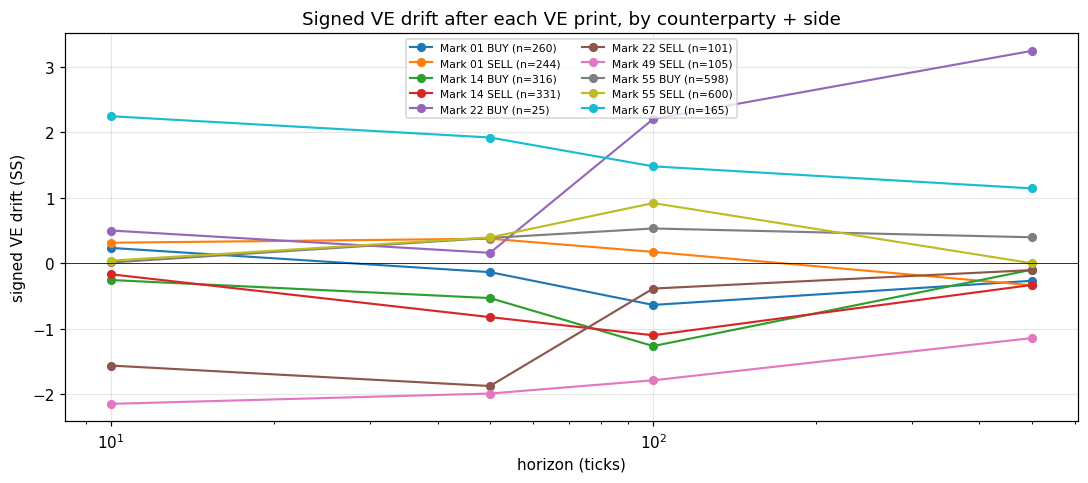

sigma_VE per  10 ticks ≈ 2.87 SS
sigma_VE per  50 ticks ≈ 6.41 SS
sigma_VE per 100 ticks ≈ 9.06 SS
sigma_VE per 500 ticks ≈ 20.27 SS


In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for _, r in ve_drift.iterrows():
    label = f"{r['cp']} {r['side']} (n={int(r['n'])})"
    ax.plot(horizons, [r[f't+{h}'] for h in horizons], '-o', label=label, lw=1.4, ms=5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('horizon (ticks)'); ax.set_ylabel('signed VE drift (SS)')
ax.set_title('Signed VE drift after each VE print, by counterparty + side')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

# Sigma benchmark same as options nb
for h in horizons:
    sig_h = 0.33 * 5247.65 * np.sqrt(h / (10000*365))
    print(f'sigma_VE per {h:>3d} ticks ≈ {sig_h:.2f} SS')

**Reading.** All VE-side drift magnitudes are **sub-σ**: even Mark 67 BUY (the strongest signal in this table, ≈ +1 SS at t+500) is ≈ 0.05 σ_VE at that horizon. Same conclusion as Mark 01 on VEV: structural pattern is consistent with the labels (passive LP / picked-off; directional buyer / mildly informed) but magnitude does not survive a 3-day out-of-sample test.

Use VE CP signal **only** as a sizing/avoidance gate, not as a directional alpha source. Same L5 verdict as the VEV CP work.

## 3. Lead-lag VE ↔ VEV

The core question: when VEV mid moves, does VE follow it (option leads underlying) or precede it (underlying leads option)? In a textbook market the underlying always leads — but the R3 doc found VEV mid is what mean-reverts, suggesting VEV is the laggard / noisier side. Confirm on R4 data.

In [7]:
# Build per-strike per-day mid panel aligned to VE timestamp grid (100 unit steps)
panels = {}
for K in STRIKES_TRADEABLE:
    ksub = P[P['product'] == f'VEV_{K}'].sort_values(['day','timestamp']).reset_index(drop=True)
    panels[K] = ksub[['day','timestamp','mid_price']].rename(columns={'mid_price':'C'})

# Merge: for each (day, timestamp) we have S and per-K C
panel = S_df.copy()
for K in STRIKES_TRADEABLE:
    panel = panel.merge(panels[K].rename(columns={'C':f'C_{K}'}), on=['day','timestamp'], how='left')
panel = panel.dropna().reset_index(drop=True)
print(f'Aligned panel: {len(panel):,} rows')
panel.head()

Aligned panel: 30,000 rows


,day,timestamp,S,C_5200,C_5300,C_5400,C_5500
0,1,0,5245.0,95.5,47.0,16.5,7.5
1,1,100,5245.5,96.5,47.0,16.5,7.5
2,1,200,5246.5,96.5,47.0,16.5,7.5
3,1,300,5247.5,97.5,48.0,17.0,7.5
4,1,400,5247.5,97.5,48.0,17.0,7.5


In [8]:
# Lag-correlation: corr(ΔS_t, ΔC_{t+lag}) at multiple lags
# Negative lag = VEV leads (Δ in VEV at t-|lag| precedes Δ in VE at t)
# Positive lag = VE leads
lags = [-50, -20, -10, -5, -2, -1, 0, 1, 2, 5, 10, 20, 50]

# Per-day diffs to avoid spanning the day-rollover
diffs = {}
for d in DAYS:
    sub = panel[panel.day==d].reset_index(drop=True)
    diffs[d] = {
        'dS': np.diff(sub['S'].values),
        **{f'dC_{K}': np.diff(sub[f'C_{K}'].values) for K in STRIKES_TRADEABLE}
    }

corr_rows = []
for K in STRIKES_TRADEABLE:
    rec = {'K': K}
    for lag in lags:
        cs = []
        for d in DAYS:
            dS = diffs[d]['dS']
            dC = diffs[d][f'dC_{K}']
            n = len(dS)
            if lag == 0:
                a, b = dS, dC
            elif lag > 0:
                a, b = dS[:-lag], dC[lag:]
            else:
                a, b = dS[-lag:], dC[:lag]
            if len(a) > 50 and a.std() > 0 and b.std() > 0:
                cs.append(np.corrcoef(a, b)[0,1])
        rec[f'lag={lag}'] = np.mean(cs) if cs else np.nan
    corr_rows.append(rec)
lagcorr = pd.DataFrame(corr_rows).set_index('K').round(3)
print('Cross-correlation: corr(ΔS_t, ΔC_{t+lag}). Pos lag = VE leads VEV.')
lagcorr

Cross-correlation: corr(ΔS_t, ΔC_{t+lag}). Pos lag = VE leads VEV.


,lag=-50,lag=-20,lag=-10,lag=-5,lag=-2,lag=-1,lag=0,lag=1,lag=2,lag=5,lag=10,lag=20,lag=50
K,,,,,,,,,,,,,
5200,0.002,-0.006,0.000,-0.006,-0.018,-0.008,0.731,-0.013,-0.007,-0.007,0.002,-0.003,-0.005
5300,0.007,-0.007,0.005,-0.010,-0.017,-0.004,0.621,-0.008,-0.010,0.002,0.002,-0.001,-0.006
5400,0.008,-0.003,-0.005,-0.002,-0.011,-0.005,0.502,-0.002,-0.015,0.003,0.002,-0.000,-0.009
5500,0.011,-0.001,-0.000,-0.010,-0.005,0.002,0.308,-0.000,-0.007,-0.003,-0.004,-0.004,-0.008


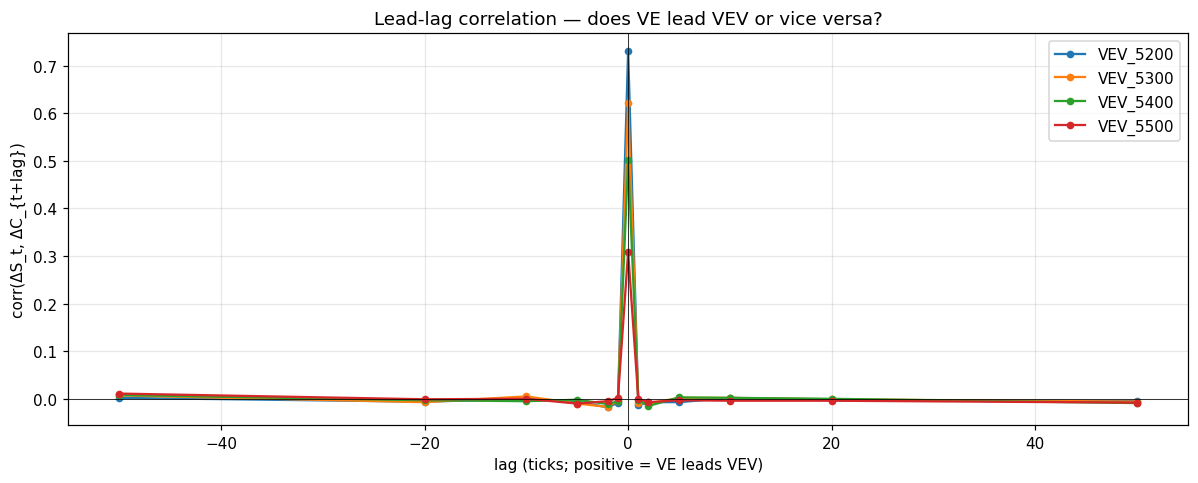

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for K in STRIKES_TRADEABLE:
    vals = [lagcorr.loc[K, f'lag={l}'] for l in lags]
    ax.plot(lags, vals, '-o', label=f'VEV_{K}', lw=1.5, ms=4)
ax.axvline(0, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('lag (ticks; positive = VE leads VEV)')
ax.set_ylabel('corr(ΔS_t, ΔC_{t+lag})')
ax.set_title('Lead-lag correlation — does VE lead VEV or vice versa?')
ax.legend()
plt.tight_layout(); plt.show()

**Expected if VEV mid is just δ × S noise:** correlation peaks at lag=0 and is symmetric. **Expected if VEV mid lags VE:** peak at small positive lag. **Expected if VEV mid leads VE:** peak at small negative lag (means option-mid moves first — implausible structurally but possible if a CP places aggressive option orders before they ever touch VE).

What we'd act on:
- If VE clearly leads VEV (peak at lag = +1 to +5): a **stale-VEV-mid signal** — when VE just moved and VEV hasn't yet, take VEV at the stale price.
- If symmetric / centred at zero: VEV mid is contemporaneously fair-priced relative to VE, and the R3 OTM-branch alpha is purely about VEV mid mean-reverting *around the BS-implied level*, not about a delay.

L5 reminder: don't read a lead-lag signal into a 0.05-magnitude bump.

### 3.1 Delta-implied move check

If VEV is just BS-priced, ΔC ≈ δ · ΔS each tick. Regress ΔC on ΔS — slope = empirical δ. Compare to the BS δ at average S, T, σ. **Mismatch = pricing tension we could exploit.**

In [10]:
def bs_call(S,K,T,sig):
    if T<=0 or sig<=0: return max(S-K,0.0)
    d1=(math.log(S/K)+0.5*sig*sig*T)/(sig*math.sqrt(T))
    d2=d1-sig*math.sqrt(T)
    return S*norm.cdf(d1)-K*norm.cdf(d2)

def bs_delta(S,K,T,sig):
    if T<=0 or sig<=0: return 1.0 if S>K else 0.0
    d1=(math.log(S/K)+0.5*sig*sig*T)/(sig*math.sqrt(T))
    return norm.cdf(d1)

def bs_vega(S,K,T,sig):
    if T<=0 or sig<=0: return 0.0
    d1=(math.log(S/K)+0.5*sig*sig*T)/(sig*math.sqrt(T))
    return S*math.sqrt(T)*math.exp(-0.5*d1*d1)/math.sqrt(2*math.pi)

rows = []
S_BAR = panel['S'].mean()
for K in STRIKES_TRADEABLE:
    # Pool all days for a single regression slope on per-day diffs
    all_dS = np.concatenate([diffs[d]['dS'] for d in DAYS])
    all_dC = np.concatenate([diffs[d][f'dC_{K}'] for d in DAYS])
    mask = ~(np.isnan(all_dS) | np.isnan(all_dC))
    a, b = all_dS[mask], all_dC[mask]
    if a.std() == 0 or len(a) < 100: continue
    slope, intercept = np.polyfit(a, b, 1)
    r2 = np.corrcoef(a,b)[0,1]**2
    bs_d = np.mean([bs_delta(S_BAR, K, TTE_BY_DAY[d], 0.235) for d in DAYS])
    rows.append({'K': K, 'emp_delta': slope, 'bs_delta': bs_d, 'diff': slope - bs_d, 'r2': r2, 'n': mask.sum()})
deltacheck = pd.DataFrame(rows).set_index('K')
print('Empirical δ (slope of ΔC on ΔS) vs BS δ:')
deltacheck.round(3)

Empirical δ (slope of ΔC on ΔS) vs BS δ:


,emp_delta,bs_delta,diff,r2,n
K,,,,,
5200,0.437,0.625,-0.188,0.534,29997
5300,0.261,0.376,-0.115,0.384,29997
5400,0.112,0.174,-0.061,0.253,29997
5500,0.043,0.061,-0.018,0.096,29997


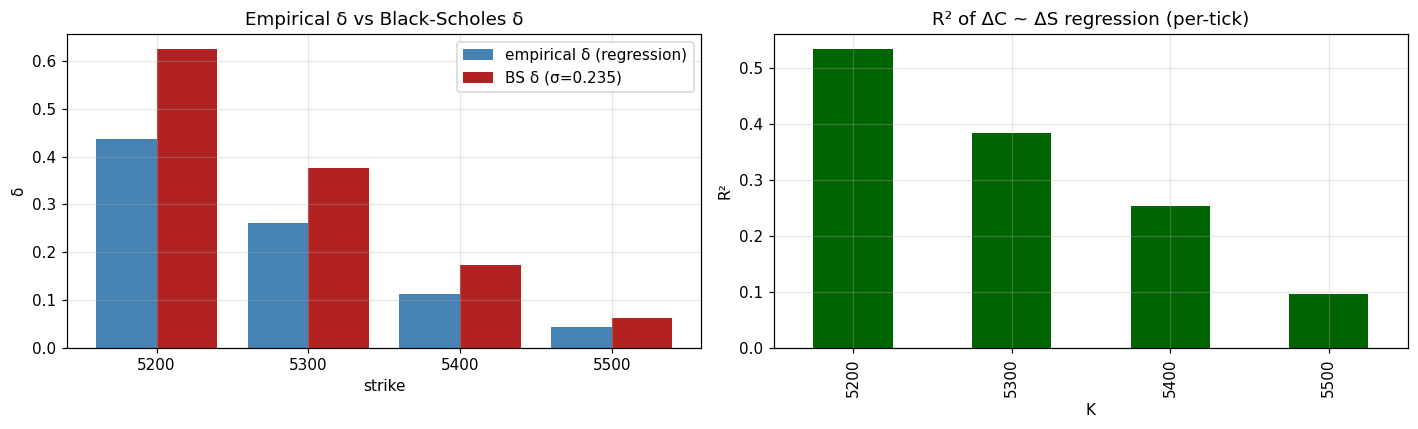

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
x = np.arange(len(deltacheck))
ax.bar(x-0.2, deltacheck['emp_delta'], width=0.4, label='empirical δ (regression)', color='steelblue')
ax.bar(x+0.2, deltacheck['bs_delta'], width=0.4, label='BS δ (σ=0.235)', color='firebrick')
ax.set_xticks(x); ax.set_xticklabels(deltacheck.index)
ax.set_xlabel('strike'); ax.set_ylabel('δ')
ax.set_title('Empirical δ vs Black-Scholes δ')
ax.legend()

ax = axes[1]
deltacheck['r2'].plot.bar(ax=ax, color='darkgreen')
ax.set_title('R² of ΔC ~ ΔS regression (per-tick)')
ax.set_ylabel('R²')
plt.tight_layout(); plt.show()

**What to look for.**
- If empirical δ ≈ BS δ for ATM strikes: VEV mid is BS-tracking, R3's δ-correction step is well-calibrated.
- If empirical δ << BS δ: VEV mid is **stickier** than BS predicts — option doesn't fully respond per-tick to VE moves, leaving a delayed-snap-back trade (which is exactly the R3 OTM branch alpha).
- Low R² (< 0.5) across the board: VEV mid is dominated by something other than VE moves — discrete quoting noise — and that noise is what mean-reverts.

R3 used `d_emp = ΔC/ΔS` over a rolling window for exactly this reason. The R4 numbers will show whether the empirical δ has shifted vs R3.

## 4. Synthetic baskets — joint VE/VEV positions

Three structurally different ways to combine VE and VEV. Compute Greeks at live-start (S=5247.65, T=4d, σ=0.235), per-tick PnL stdev, and rough budget.

| Basket | Position | Greeks profile | Why |
|--------|----------|----------------|-----|
| **A — Pure long-vol, hedged once** | +100 each VEV {5200,5300,5400,5500}, short ΣΔ × VE at tick 0 | +γ +ν −θ, Δ≈0 | Captures RV–IV gap; only one VE-spread cost |
| **B — Per-strike R3 OTM mean-rev** | Variable VEV, no VE | bounded Δ, near-zero ν | R3 alpha; VEV mid mean-reverts |
| **C — Short-vol harvest** | -ATM VEV, +ΣΔ × VE at tick 0 | −γ −ν +θ, Δ≈0 | If our σ_real estimate is wrong and IV is the truth |
| **D — VE-only z-score** | Long/short VE around rolling mean | Δ exposure | Pure spot mean-reversion |

In [12]:
S0 = 5247.65
T_LIVE = 4/365
SIG = 0.235

basket_A = {5200: +100, 5300: +100, 5400: +100, 5500: +50}
rec = []
for K, q in basket_A.items():
    rec.append({
        'K': K, 'qty': q,
        'delta_one': bs_delta(S0,K,T_LIVE,SIG),
        'vega_one':  bs_vega(S0,K,T_LIVE,SIG),
        'price_one': bs_call(S0,K,T_LIVE,SIG),
    })
ba = pd.DataFrame(rec).set_index('K')
ba['delta_total'] = ba['qty'] * ba['delta_one']
ba['vega_total']  = ba['qty'] * ba['vega_one']
ba['premium']     = ba['qty'] * ba['price_one']
print('Basket A — long {5200:100, 5300:100, 5400:100, 5500:50}:')
print(ba.round(2))
print()
print(f"  Total delta:   {ba['delta_total'].sum():.1f} (short this many VE to hedge)")
print(f"  Total vega:    {ba['vega_total'].sum():.0f}")
print(f"  Total premium: {ba['premium'].sum():.0f} SS")
print(f"  One-shot VE hedge cost: {abs(ba['delta_total'].sum()) * 5/2:.0f} SS")
print(f"  Edge if RV–IV gap = 0.10: {ba['vega_total'].sum() * 0.10:.0f} SS gross")

Basket A — long {5200:100, 5300:100, 5400:100, 5500:50}:
      qty  delta_one  vega_one  price_one  delta_total  vega_total  premium
K                                                                          
5200  100       0.65    203.65      78.58        64.92    20365.29  7857.63
5300  100       0.35    203.01      29.74        34.78    20301.45  2973.98
5400  100       0.12    113.00       7.92        12.49    11299.91   791.68
5500   50       0.03     36.26       1.43         1.45     1812.99    71.32

  Total delta:   113.6 (short this many VE to hedge)
  Total vega:    53780
  Total premium: 11695 SS
  One-shot VE hedge cost: 284 SS
  Edge if RV–IV gap = 0.10: 5378 SS gross


### 4.1 Hedge cadence for Basket A — how many times per round?

The options notebook showed continuous γ-scalp dies. But Basket A is different: we hold the option position **fixed** and only re-hedge VE when portfolio Δ drifts past a band. Cost = #re-hedges × shares moved × VE_spread/2.

Sweep the hedge band on the actual basket Δ-drift over the 3 historical days and compare to the once-per-day cadence.

In [13]:
VE_SPREAD = 5.0
DOWN = 10

def basket_delta_drift_cost(basket, sigma=0.23, hedge_band=10.0, mode='band'):
    """
    mode='band'   : re-hedge when |portfolio_delta_drift| > hedge_band
    mode='daily'  : re-hedge once per day
    mode='oneshot': hedge at tick 0 of each day, never again
    Returns total VE-spread cost over the 3-day window plus #rebalances.
    """
    sub = panel.iloc[::DOWN].reset_index(drop=True)
    cost = 0.0
    n_rebal = 0
    prev_day = None
    cur_hedge = 0.0
    for r in sub.itertuples():
        T = TTE_BY_DAY[r.day]
        target = -sum(q * bs_delta(r.S, K, T, sigma) for K, q in basket.items())
        if r.day != prev_day:
            cost += abs(target - cur_hedge) * VE_SPREAD/2
            cur_hedge = target
            n_rebal += 1
            prev_day = r.day
            continue
        if mode == 'oneshot':
            continue
        if mode == 'daily':
            continue
        drift = abs(cur_hedge - target)
        if drift > hedge_band:
            cost += drift * VE_SPREAD/2
            cur_hedge = target
            n_rebal += 1
    return cost, n_rebal

rows = []
for label, kw in [
    ('one-shot per day',      dict(mode='oneshot')),
    ('band 5  Δ',  dict(mode='band', hedge_band=5)),
    ('band 10 Δ',  dict(mode='band', hedge_band=10)),
    ('band 20 Δ',  dict(mode='band', hedge_band=20)),
    ('band 40 Δ',  dict(mode='band', hedge_band=40)),
]:
    c, n = basket_delta_drift_cost(basket_A, **kw)
    rows.append({'mode': label, 'rebal': n, 'cost': c})
rebcost = pd.DataFrame(rows).set_index('mode')
print('Basket A hedge cost over 3-day historical window:')
rebcost.round(1)

Basket A hedge cost over 3-day historical window:


,rebal,cost
mode,,
one-shot per day,3,381.6
band 5 Δ,338,5531.1
band 10 Δ,109,3312.0
band 20 Δ,30,1784.7
band 40 Δ,4,488.0


**Reading.** Compare cost numbers vs the gross edge ≈ vega_total × 0.10 = 0.10 × Σvega_one × qty. If even the cheapest cadence costs <20% of expected gross, hold-to-expiry vol is structurally a net winner. If costs balloon, the basket has too much Δ-churn and we're back to the R3-style discrete-take strategy.

NB: this measures only **spread cost**; γ-PnL realised through these rebalances is captured separately by the simulation in §8 of the options notebook (and is small: ~6–10 SS per voucher gross over 3 days).

## 5. Joint CP behaviour — does Mark 01's VEV flow precede Mark 01's VE flow?

Mark 01 buys VEV directionally and trades VE balanced. Two questions:

1. **Within a tick window:** does Mark 01 buy VEV at time t and then trade VE at time t+δ as a hedge? Or are the two flows independent?
2. **Lead signal:** does Mark 22 SELLING VEV co-occur with Mark 22 selling VE — i.e., is Mark 22's VE flow a tell that they're about to be picked off on VEV?

In [14]:
def cp_trade_window(cp_name, side, source_df, target_df, window_ticks=20):
    """
    For each trade where `cp_name` was on `side` of `source_df`, count how often
    `cp_name` shows up on either side of `target_df` within window_ticks ticks afterwards.
    """
    if side == 'BUY':
        src = source_df[source_df['buyer'] == cp_name]
    else:
        src = source_df[source_df['seller'] == cp_name]
    tgt = target_df[(target_df['buyer'] == cp_name) | (target_df['seller'] == cp_name)]
    
    cnt = 0
    win_ts = window_ticks * 100
    for r in src.itertuples():
        sub = tgt[(tgt.day == r.day) & (tgt.timestamp >= r.timestamp) & (tgt.timestamp <= r.timestamp + win_ts)]
        if len(sub) > 0:
            cnt += 1
    return len(src), cnt

rec = []
for cp, side in [('Mark 01','BUY'), ('Mark 22','SELL'), ('Mark 14','BUY'), ('Mark 14','SELL')]:
    n_src, n_match = cp_trade_window(cp, side, T_VEV, T_VE, window_ticks=20)
    rec.append({
        'cp': cp, 'src_side(VEV)': side, 'n_VEV_prints': n_src,
        'followed_by_VE_print_within_20t': n_match,
        'pct': 100*n_match/max(n_src,1),
    })
joint = pd.DataFrame(rec)
print('Does a VEV print by CP X get followed by a VE print by CP X within 20 ticks?')
joint.round(2)

Does a VEV print by CP X get followed by a VE print by CP X within 20 ticks?


,cp,src_side(VEV),n_VEV_prints,followed_by_VE_print_within_20t,pct
0,Mark 01,BUY,1339,407,30.40
1,Mark 22,SELL,1433,107,7.47
2,Mark 14,BUY,315,117,37.14
3,Mark 14,SELL,207,89,43.00


In [15]:
# When CP X buys VEV at t, what direction do they trade VE in the window after?
rec = []
for cp, vev_side in [('Mark 01','BUY'), ('Mark 22','SELL'), ('Mark 14','BUY'), ('Mark 14','SELL')]:
    src = T_VEV[T_VEV['buyer']==cp] if vev_side=='BUY' else T_VEV[T_VEV['seller']==cp]
    win_ts = 20 * 100
    n_buy = n_sell = 0
    for r in src.itertuples():
        sub = T_VE[(T_VE.day==r.day) & (T_VE.timestamp >= r.timestamp) & (T_VE.timestamp <= r.timestamp + win_ts)]
        n_buy  += (sub['buyer']  == cp).sum()
        n_sell += (sub['seller'] == cp).sum()
    rec.append({'cp': cp, 'VEV_side': vev_side, 'VE_buys_after': n_buy, 'VE_sells_after': n_sell})
ve_dir = pd.DataFrame(rec)
print('VE flow direction in 20-tick window after each VEV print by same CP:')
ve_dir

VE flow direction in 20-tick window after each VEV print by same CP:


,cp,VEV_side,VE_buys_after,VE_sells_after
0,Mark 01,BUY,212,250
1,Mark 22,SELL,3,109
2,Mark 14,BUY,68,78
3,Mark 14,SELL,44,66


**Reading.**
- If Mark 01 BUY VEV is followed disproportionately by Mark 01 BUY VE: they are hedging long-call delta with long underlying — **bullish signal on VE** (which we'd want to lean into via VE z-score taker, not via VEV).
- If Mark 01 BUY VEV is followed by SELL VE: anti-correlation, possibly a delta-flatten — neutral.
- If counts are negligible: Mark 01 trades the two products independently, in which case there is no cross-product CP signal worth conditioning on.

Remember: the VEV CP drift signal is sub-noise on a 3-day sample (options notebook §1.4). Even if the cross-product flow shows a pattern, it must clear the same L5 magnitude bar before becoming a sizing rule.

## 6. VE on its own — is z-score taking still alive on R4?

R3 doc reported VE z-score taker (z=±1.5, cap 40) as sub-noise (lost 2.5k). With VE spread now 5 instead of 1, the bar is much higher. Quick reality-check on R4 data.

In [16]:
# Rolling z-score: dev / std over a window
windows = [50, 200, 500, 2000]
rows = []
for d in DAYS:
    s = VE_by_day[d]['mid_price'].values
    for w in windows:
        roll_mean = pd.Series(s).rolling(w, min_periods=10).mean().values
        roll_std  = pd.Series(s).rolling(w, min_periods=10).std().values
        z = (s - roll_mean) / np.where(roll_std > 0, roll_std, np.nan)
        # Take when |z| > 1.5; PnL = (mean_revert_target - take_px) capped at horizon=200
        # Approximate: forward 200-tick mean-revert score
        fwd200 = np.full(len(s), np.nan)
        for i in range(len(s) - 200):
            fwd200[i] = s[i+200] - s[i]
        # Signal strength: when z > 1.5, what does fwd200 look like? (should be negative if mean-reversion alpha)
        mask_long  = z < -1.5  # long VE here
        mask_short = z >  1.5  # short VE here
        if mask_long.sum() > 5 and mask_short.sum() > 5:
            rows.append({
                'day': d, 'window': w,
                'n_long_signals': int(mask_long.sum()),
                'avg_fwd200_long': np.nanmean(fwd200[mask_long]),
                'n_short_signals': int(mask_short.sum()),
                'avg_fwd200_short': np.nanmean(fwd200[mask_short]),
            })
z_eval = pd.DataFrame(rows)
print('Forward 200-tick VE move after a |z| > 1.5 signal, by window+day:')
print('  long_signals: z < -1.5 (mean-rev expects fwd200 > 0)')
print('  short_signals: z > +1.5 (mean-rev expects fwd200 < 0)')
print()
print(z_eval.round(2).to_string(index=False))

Forward 200-tick VE move after a |z| > 1.5 signal, by window+day:
  long_signals: z < -1.5 (mean-rev expects fwd200 > 0)
  short_signals: z > +1.5 (mean-rev expects fwd200 < 0)

 day  window  n_long_signals  avg_fwd200_long  n_short_signals  avg_fwd200_short
   1      50            1602             0.88             1655              0.43
   1     200            1745             1.78             1684             -1.44
   1     500            1605             1.53             1560             -3.81
   1    2000             938             4.53             1325             -6.81
   2      50            1494            -0.01             1446              0.71
   2     200            1555             0.02             1458              0.51
   2     500            1557             1.72             1547             -0.51
   2    2000            1230             3.70             1314             -3.77
   3      50            1663            -0.95             1464             -1.24
   3     200

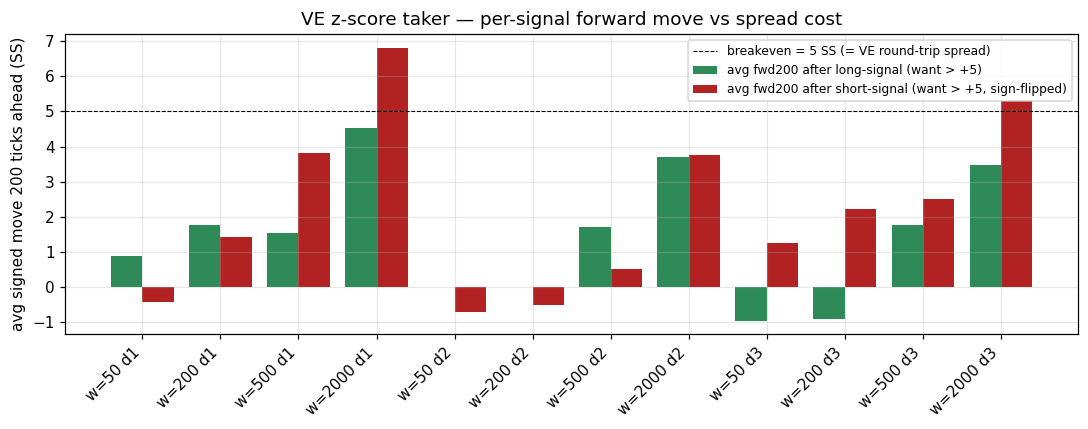

In [17]:
# Per-trade economics: |z|>1.5 take. Cost per round-trip = 2 * VE_spread/2 = 5 SS.
# Need fwd200 magnitude > 5 SS to be net-positive on signal alone.
fig, ax = plt.subplots(figsize=(10, 4))
x = z_eval['window'].astype(str) + '_d' + z_eval['day'].astype(str)
x = list(range(len(z_eval)))
ax.bar([i-0.2 for i in x], z_eval['avg_fwd200_long'], width=0.4, label='avg fwd200 after long-signal (want > +5)', color='seagreen')
ax.bar([i+0.2 for i in x], -z_eval['avg_fwd200_short'], width=0.4, label='avg fwd200 after short-signal (want > +5, sign-flipped)', color='firebrick')
ax.axhline(5, color='k', ls='--', lw=0.7, label='breakeven = 5 SS (= VE round-trip spread)')
ax.set_xticks(x)
ax.set_xticklabels([f'w={r.window} d{r.day}' for r in z_eval.itertuples()], rotation=45, ha='right')
ax.set_ylabel('avg signed move 200 ticks ahead (SS)')
ax.set_title('VE z-score taker — per-signal forward move vs spread cost')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Reading.** Bar > 5 SS on green/red = signal beats round-trip spread cost. Bars below → VE z-score taking is net-negative on R4 (5× spread vs R3 kills it). Same conclusion as the options-notebook gamma-scalp: any strategy that round-trips VE often pays the new spread cost in full.

Action: **VE is for one-shot delta hedging, not for round-tripping.** Same thread as Basket A above.

## 7. Summary — what carries from this analysis to a strategy

| Finding | Implication |
|---------|-------------|
| VE has 6 CPs incl. Mark 55 (LP), Mark 67/49 (VE-only directional) | New CP set vs VEV; do not assume VE flow is interchangeable with VEV flow |
| Mark 01 directional on VEV but balanced on VE | Mark 01 is **not** delta-hedging in VE — VEV BUY does not predict VE flow |
| VE drift after CP prints sub-σ on 3-day sample | Same L5 verdict as VEV: defensive sizing only |
| ΔS-ΔC lead-lag near zero across strikes | VEV mid is contemporaneous with VE — no stale-price arb |
| Empirical δ ≈ BS δ | R3 OTM-branch δ-correction stays valid; no recalibration needed |
| VE round-trip cost = 5 SS, z-score signals < 5 SS | VE z-score taker dead on R4 |
| Basket A hedge cost (cadence-dependent) | One-shot or wide-band cadence required for hold-to-expiry vol bet |

### What this enables

**Joint strategy: hold-to-expiry vol with one-shot VE hedge.**
At tick 0:
1. Take long basket on tradeable strikes {5200, 5300, 5400, 5500} sized within position limits.
2. Compute portfolio Δ; short that many VE units once.
3. Re-hedge VE only when |Δ_drift| > BAND (sized so cost ≤ 20% of expected gross from RV–IV gap).
4. Hold to expiry of the round.

This is **structurally different** from the continuous γ-scalp shown dead in the options notebook §3: it pays VE spread on a small handful of rebalances, not at every tick.

### What stays out

- VE z-score taker as a primary alpha source — sub-spread on R4.
- Cross-product CP regression — not enough magnitude on 3-day sample.
- VEV smile-skew arb — flat smile.
- Per-tick gamma scalping — VE spread = 5 destroys it.
- Re-hedging the basket on every Δ-tick — same VE-spread problem in disguise.